# Class Assignment 5: Predicting Apple Stocks using RNN (LSTM) - Recurrent Neural Network
 
Up to now we've used neural networks to classify static images. Now we will be studying <a href='https://en.wikipedia.org/wiki/Recurrent_neural_network'>Recurrent Neural Networks</a> (RNNs) which is specialized for time series data or text data, where previous affects the next.

The basic model of a single RNN unit is represented as:

$$ \mathbf{h_t} = f(\mathbf{W}_{x}\mathbf{x}_t + \mathbf{W}_{h}\mathbf{h}_{t-1} + \mathbf{b}) $$

Where:
- $h$ is the hidden size, and
- $\mathbf{h}_t$ $\in (h, )$ is the hidden state at time $t$ ,
- $\mathbf{x}_t$ $\in (n, )$ is the input at time $t$,
- $\mathbf{W}_{x}$ $\in (h, n)$ is the weight matrix for inputs to hidden layer,
- $\mathbf{W}_{h}$ $\in (h, h)$ is the weight matrix for hidden layer to hidden layer,
- $\mathbf{b}$ $\in (h, )$ is the hidden bias ,
- $f$ is the activation function.

## Predict Apple Stock using LSTM

Here we will be using 30 days in the past to predict the next 1 day.

To do so, we will split the last 15 days as test set, where we will use our model to slowly predict day by day, until we reached the 15 days.

In [147]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Load data

Class assignment 5 task:

1.  Get the apple stock dataset from the Downloads section

2.  Play the notebook under my Github repo > 03 - Deep Learning > RNN > 01. Recurrent Neural Network

In [148]:
df = pd.read_csv("../datasets/ca5/appl_1980_2014.csv")
df.head()

,Date,Open,High,Low,Close,Volume,Adj Close
0,2014-07-08,96.27,96.80,93.92,95.35,65130000,95.35
1,2014-07-07,94.14,95.99,94.10,95.97,56305400,95.97
2,2014-07-03,93.67,94.10,93.20,94.03,22891800,94.03
3,2014-07-02,93.87,94.06,93.09,93.48,28420900,93.48
4,2014-07-01,93.52,94.07,93.13,93.52,38170200,93.52


In [149]:
# standardize column names als small letters and spaces to underscores
df.columns = [col.lower().replace(' ', '_') for col in df.columns]
df.head()

,date,open,high,low,close,volume,adj_close
0,2014-07-08,96.27,96.80,93.92,95.35,65130000,95.35
1,2014-07-07,94.14,95.99,94.10,95.97,56305400,95.97
2,2014-07-03,93.67,94.10,93.20,94.03,22891800,94.03
3,2014-07-02,93.87,94.06,93.09,93.48,28420900,93.48
4,2014-07-01,93.52,94.07,93.13,93.52,38170200,93.52


In [150]:
#make sure your data is of actually date format
print(df.info())
df.date = pd.to_datetime(df.date)
df.info(), df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8465 entries, 0 to 8464
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       8465 non-null   object 
 1   open       8465 non-null   float64
 2   high       8465 non-null   float64
 3   low        8465 non-null   float64
 4   close      8465 non-null   float64
 5   volume     8465 non-null   int64  
 6   adj_close  8465 non-null   float64
dtypes: float64(5), int64(1), object(1)
memory usage: 463.1+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8465 entries, 0 to 8464
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       8465 non-null   datetime64[ns]
 1   open       8465 non-null   float64       
 2   high       8465 non-null   float64       
 3   low        8465 non-null   float64       
 4   close      8465 non-null   float64       
 5   volume     8465 non-null 

(None,
         date   open   high    low  close    volume  adj_close
 0 2014-07-08  96.27  96.80  93.92  95.35  65130000      95.35
 1 2014-07-07  94.14  95.99  94.10  95.97  56305400      95.97
 2 2014-07-03  93.67  94.10  93.20  94.03  22891800      94.03
 3 2014-07-02  93.87  94.06  93.09  93.48  28420900      93.48
 4 2014-07-01  93.52  94.07  93.13  93.52  38170200      93.52)

### Choose the timeframe

Keep stock data above 2009 and below 2014

In [151]:
print(df.date.sort_values().dt.year.unique())

cond = (df.date.dt.year > 2009) & (df.date.dt.year < 2014)
df = df[cond]

df.head()

[1980 1981 1982 1983 1984 1985 1986 1987 1988 1989 1990 1991 1992 1993
 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003 2004 2005 2006 2007
 2008 2009 2010 2011 2012 2013 2014]


,date,open,high,low,close,volume,adj_close
129,2013-12-31,554.17,561.28,554.00,561.02,55771100,79.23
130,2013-12-30,557.46,560.09,552.32,554.52,63407400,78.31
131,2013-12-27,563.82,564.41,559.50,560.09,56471100,79.10
132,2013-12-26,568.10,569.50,563.38,563.90,51002000,79.63
133,2013-12-24,569.89,571.88,566.03,567.67,41888700,80.17


In [152]:
df.date.dt.year.unique()

array([2013, 2012, 2011, 2010], dtype=int32)

### Set date as index

In [153]:
df = df.set_index('date')
df.index

DatetimeIndex(['2013-12-31', '2013-12-30', '2013-12-27', '2013-12-26',
               '2013-12-24', '2013-12-23', '2013-12-20', '2013-12-19',
               '2013-12-18', '2013-12-17',
               ...
               '2010-01-15', '2010-01-14', '2010-01-13', '2010-01-12',
               '2010-01-11', '2010-01-08', '2010-01-07', '2010-01-06',
               '2010-01-05', '2010-01-04'],
              dtype='datetime64[ns]', name='date', length=1006, freq=None)

In [154]:
df.head()

,open,high,low,close,volume,adj_close
date,,,,,,
2013-12-31,554.17,561.28,554.00,561.02,55771100,79.23
2013-12-30,557.46,560.09,552.32,554.52,63407400,78.31
2013-12-27,563.82,564.41,559.50,560.09,56471100,79.10
2013-12-26,568.10,569.50,563.38,563.90,51002000,79.63
2013-12-24,569.89,571.88,566.03,567.67,41888700,80.17


In [155]:
df.sort_index(ascending=True, inplace=True)

In [156]:
df.head()

,open,high,low,close,volume,adj_close
date,,,,,,
2010-01-04,213.43,214.50,212.38,214.01,123432400,29.22
2010-01-05,214.60,215.59,213.25,214.38,150476200,29.27
2010-01-06,214.38,215.23,210.75,210.97,138040000,28.81
2010-01-07,211.75,212.00,209.05,210.58,119282800,28.75
2010-01-08,210.30,212.00,209.06,211.98,111902700,28.94


## 2. EDA

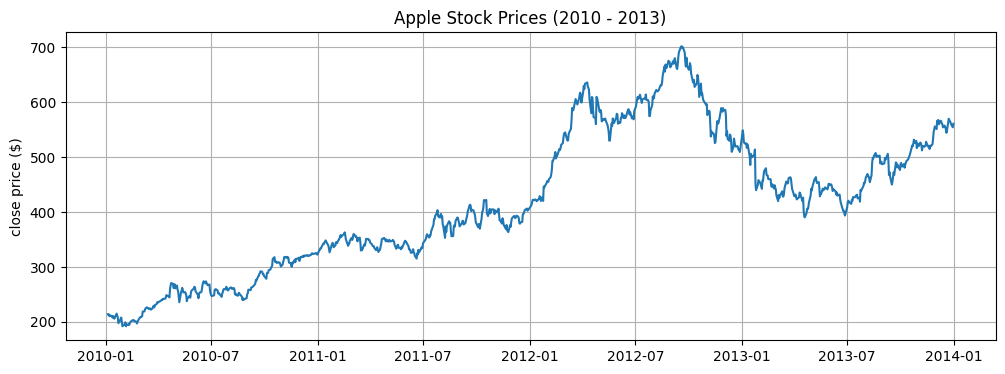

In [157]:
#plot the apple stocks
plt.figure(figsize=(12, 4))
plt.title('Apple Stock Prices (2010 - 2013)')
plt.ylabel('close price ($)')
plt.grid()
plt.plot(df.close)

## 3. Train test split

Here we will use the last 30 days of the training set to predict the next day.  Then we will autoregressively fill the next days until we reached 15 days.

In [158]:
y = df['close'].values.astype('float')
train_set = y[:-15]  #takes everything except the last 15 elements
test_set  = y[-15:]

In [159]:
type(train_set)

numpy.ndarray

In [160]:
train_set.shape, test_set.shape

((991,), (15,))

## 4. Normalization

We don't do standardization because mean is wrong.  It's better to normalize it into range of -1 and 1.

In [161]:
train_set.shape

(991,)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(-1, 1))

train_set_norm = scaler.fit_transform(train_set.reshape(-1, 1))

In [163]:
train_set_norm.min(), train_set_norm.max()

(np.float64(-0.9999999999999999), np.float64(1.0))

## 5. Prepare train set

When working with LSTM models, we start by dividing the training sequence into a series of overlapping "windows". Each window consists of a connected string of samples. The label used for comparison is equal to the next value in the sequence. In this way our network learns what value should follow a given pattern of preceding values. Note: although the LSTM layer produces a prediction for each sample in the window, we only care about the last one.

For example, say we have a series of 15 records, and a window size of 5. We feed $[x_1,..,x_5]$ into the model, and compare the prediction to $x_6$. Then we backprop, update parameters, and feed $[x_2,..,x_6]$ into the model. We compare the new output to $x_7$ and so forth up to $[x_{10},..,x_{14}]$.

To simplify matters, we'll define a function called `create_data` that builds a list of `(seq, label)` tuples. Windows overlap, so the first tuple might contain $([x_1,..,x_5],[x_6])$, the second would have $([x_2,..,x_6],[x_7])$, etc. 

Here $k$ is the width of the window. Due to the overlap, we'll have a total number of <tt>(seq, label)</tt> tuples equal to $\textrm{len}(series)-k$

In [164]:
#convert np to tensor
train_set_norm = torch.FloatTensor(train_set_norm).view(-1)
train_set_norm.shape

#define window size
ws = 30 #use 30 days in the past to predict the next day

#define function to create training set (ws days -> 1 day)
#sample 0:  Day 1 to Day 30 -> Day 31
#sample 1:  Day 2 to Day 31 -> Day 32
#...
def create_data(seq, label):
    out = []
    #array to hold the out
    #i runs from 0 to (991 - 30)
    for i in range(seq.shape[0] - label):
        x = seq[i:i+label]          # 30 days in the past
        y = seq[i+label:i+label+1]  # next day
        out.append((x, y))
    return out

chaky_data = create_data(train_set_norm, ws)


In [165]:
chaky_data[0]

(tensor([-0.9139, -0.9124, -0.9258, -0.9273, -0.9219, -0.9292, -0.9386, -0.9271,
         -0.9318, -0.9456, -0.9099, -0.9228, -0.9372, -0.9776, -0.9568, -0.9455,
         -0.9379, -0.9716, -1.0000, -0.9895, -0.9851, -0.9718, -1.0000, -0.9866,
         -0.9919, -0.9838, -0.9880, -0.9740, -0.9673, -0.9555]),
 tensor([-0.9588]))

In [166]:
len(chaky_data) # 991 - 30 = 961 --> Total days - window size = number of samples

961

In [167]:
len(train_set_norm)

991

## 6. Neural Network

A variant of RNN called LSTM, which is much more powerful.

Our model will have one LSTM layer with an input size of 1 and a hidden size of 50, followed by a fully-connected layer to reduce the output to the prediction size of 1.<br>

<div class="alert alert-info"><strong>NOTE:</strong> You will often see the terms `input_dim` and `hidden_dim` used in place of `input_size` and `hidden_size`. They mean the same thing. We'll stick to `input_size` and `hidden_size` to stay consistent with PyTorch's built-in keywords.</div>

### Example

In [168]:
sample, target = chaky_data[0]

In [169]:
sample.shape  #30 samples in a time series

torch.Size([30])

In [170]:
target.shape #this is the 31th number after the 30 samples

torch.Size([1])

In [171]:
sample_reshape = sample.reshape(sample.shape[0], 1, -1)  #(1, 30)
sample_reshape.shape, sample_reshape[:5]

(torch.Size([30, 1, 1]),
 tensor([[[-0.9139]],
 
         [[-0.9124]],
 
         [[-0.9258]],
 
         [[-0.9273]],
 
         [[-0.9219]]]))

In [172]:
lstm = nn.LSTM(1, 50)

In [173]:
out, hidden = lstm(sample_reshape)  #hidden has both h and c

In [174]:
out.shape #(length, batch size, hidden size)

torch.Size([30, 1, 50])

In [175]:
hidden[0].shape #(num layer, batch size, hidden size)

torch.Size([1, 1, 50])

In [176]:
# assert out[-1] == hidden[0]

In [177]:
out = out.view(len(out), -1)
out.shape

torch.Size([30, 50])

In [178]:
linear_layer = nn.Linear(50, 1)

In [179]:
out = linear_layer(out)
out.shape

torch.Size([30, 1])

### Network

In [180]:
class chaky_RNN(nn.Module):
    def __init__(self, input_s = 1, hs = 50, output_size = 1):
        super().__init__()
        self.hs = hs
        self.lstm = nn.LSTM(input_s, hs)  #LSTM will automatically create W(s) for us
        self.linear = nn.Linear(hs, output_size)  #take output of LSTM, project to prediction
        
    def forward(self, input_):
        out, _ = self.lstm(input_.reshape(input_.shape[0], 1, -1)) #30, 1, 1
        out    = self.linear(out.view(len(input_), -1))  #30, 50
        return out[-1]

In [181]:
torch.manual_seed(999)
model = chaky_RNN()

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [182]:
def count_parameters(model):
    params = [p.numel() for p in model.parameters() if p.requires_grad]
    for item in params:
        print(f'{item:>6}')
    print(f'______\n{sum(params):>6}')
    
count_parameters(model)

   200
 10000
   200
   200
    50
     1
______
 10651


## 7. Training

In [183]:
epochs = 100

for i in range(epochs):
    
    # tuple-unpack the chaky_data set
    for seq, y_train in chaky_data:  
        y_pred = model(seq)
        loss = criterion(y_pred, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    # print training result
    if i % 10 == 0:
        print(f'Epoch: {i:2} Loss: {loss.item():10.8f}')

Epoch:  0 Loss: 0.01146772
Epoch: 10 Loss: 0.00310121
Epoch: 20 Loss: 0.00189559
Epoch: 30 Loss: 0.00290085
Epoch: 40 Loss: 0.00394395
Epoch: 50 Loss: 0.00323838
Epoch: 60 Loss: 0.00323480
Epoch: 70 Loss: 0.00236012
Epoch: 80 Loss: 0.00220638
Epoch: 90 Loss: 0.00473966


## 8. Testing

In [184]:
# Prediction 1:
# seq = [Day 961, ..., Day 990]  # Last 30 from preds
# yhat = model(seq)  # Predicts Day 991
# preds.append(Day 991)  # Now preds has 31 values

# # Prediction 2:
# seq = [Day 962, ..., Day 991]  # Last 30 from preds (notice Day 961 dropped)
# yhat = model(seq)  # Predicts Day 992
# preds.append(Day 992)  # Now preds has 32 values

# # Prediction 3:
# seq = [Day 963, ..., Day 992]  # Last 30 from preds
# yhat = model(seq)  # Predicts Day 993
# preds.append(Day 993)

# # ... continues for 30 iterations

preds = train_set_norm[-ws:].tolist()  #start with last 30 days of training,  this is the input to predict the test set

model.eval()

for i in range(15): #we want to predict 15 days
    seq = torch.FloatTensor(preds[-ws:])  #the reason is because we keep appending on this, until we get 15 predictions, then compare to test set
    with torch.no_grad():
        yhat = model(seq)
        preds.append(yhat.item())

## 9. Plotting

In [185]:
np.array(preds[-ws:]).reshape(-1, 1).shape

(30, 1)

We want to compare our test predictions to the original data, so we need to undo the previous normalization step. Note that <tt>inverse_transform</tt> uses the most recently applied parameters; we can rescale based on the test data, but not on the previous training data.

In [186]:
#1. inverse the normalization
true_numbers = scaler.inverse_transform(np.array(preds[-ws:]).reshape(-1, 1))

In [187]:
#2. plot
x = df['close'][-ws:].index

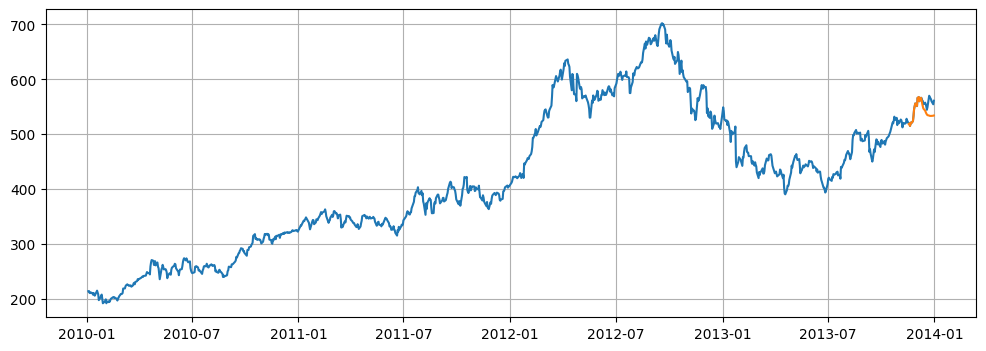

In [188]:
plt.figure(figsize=(12, 4))
plt.grid()
plt.plot(df['close'])  #historical data
plt.plot(x, true_numbers)

# Class Assignement Task
Exercise 1: Window Size Experiment

Change ws = 30 to ws = 7, then ws = 60
Retrain the model for each window size
Plot and compare the predictions
Which window size works best? Why?
What happens when window is too small or too large?

In [190]:
data_ws_60 = create_data(train_set_norm, 60)
data_ws_60[0]

(tensor([-0.9139, -0.9124, -0.9258, -0.9273, -0.9219, -0.9292, -0.9386, -0.9271,
         -0.9318, -0.9456, -0.9099, -0.9228, -0.9372, -0.9776, -0.9568, -0.9455,
         -0.9379, -0.9716, -1.0000, -0.9895, -0.9851, -0.9718, -1.0000, -0.9866,
         -0.9919, -0.9838, -0.9880, -0.9740, -0.9673, -0.9555, -0.9588, -0.9573,
         -0.9623, -0.9672, -0.9804, -0.9662, -0.9610, -0.9507, -0.9336, -0.9341,
         -0.9322, -0.9268, -0.8945, -0.8940, -0.8786, -0.8714, -0.8688, -0.8645,
         -0.8753, -0.8730, -0.8742, -0.8722, -0.8816, -0.8718, -0.8576, -0.8537,
         -0.8643, -0.8477, -0.8418, -0.8283]),
 tensor([-0.8316]))

In [200]:

def train_model(model, train_data_norm, criterion, optimizer, device, epochs):
    for epoch in range(epochs):
        for X_seq, y_train in train_data_norm:
            # Move data to device TODO use MPS non-blocking
            # X = X.to(device, non_blocking=False)
            # y = y.to(device, non_blocking=False)
            y_pred = model(X_seq)
            loss = criterion(y_pred, y_train)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        
        if epoch % 10 == 0:
            print(f'Epoch: {epoch:2} Loss: {loss.item():10.8f}')

def test_model(model, test_data_norm, ws):
    preds = test_data_norm[-ws:].tolist()

    model.eval()

    # predict 15 days
    for day in range(15):
        #the reason is because we keep appending on this, until we get 15 predictions, then compare to test set
        seq = torch.FloatTensor(preds[-ws:])
        with torch.no_grad():
            yhat = model(seq)
            preds.append(yhat.item())
    
    return preds



def predict_future(model, norm_train_set, norm_test_set, ws):
    # Create dataset with window size ws
    train_data_window = create_data(norm_train_set, ws)

    ##############################
    # Our model will have one LSTM layer with an input size of 1 and a hidden size of 50, 
    # followed by a fully-connected layer to reduce the output to the prediction size of 1
    ###############################
    # reshape data for model input
    sample_reshape = sample.reshape(sample.shape[0], 1, -1) 
    print(f'Reshaped shape: {sample_reshape.shape}')

    # Define the model
    model = chaky_RNN()

    # Loss and optimizer
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


    # Train the model
    train_model(model, train_data_window, criterion, optimizer, device='cpu', epochs=100)

    # Test model
    preds = test_model(model,norm_train_set, ws)

    #Plot the data
    # reverse normalization
    true_numbers = scaler.inverse_transform(np.array(preds[-ws:]).reshape(-1, 1))
    #2. plot
    x = df['close'][-ws:].index
    plt.figure(figsize=(12, 4))
    plt.title(f'Apple Stock Prices (2010 - 2013) prediction based on {ws} days window size ')
    plt.grid()
    plt.plot(df['close'])  #historical data
    plt.plot(x, true_numbers)


Reshaped shape: torch.Size([30, 1, 1])
Epoch:  0 Loss: 0.00785242
Epoch: 10 Loss: 0.00588876
Epoch: 20 Loss: 0.00430083
Epoch: 30 Loss: 0.00365552
Epoch: 40 Loss: 0.00332406
Epoch: 50 Loss: 0.00301870
Epoch: 60 Loss: 0.00304862
Epoch: 70 Loss: 0.00274190
Epoch: 80 Loss: 0.00234956
Epoch: 90 Loss: 0.00206067


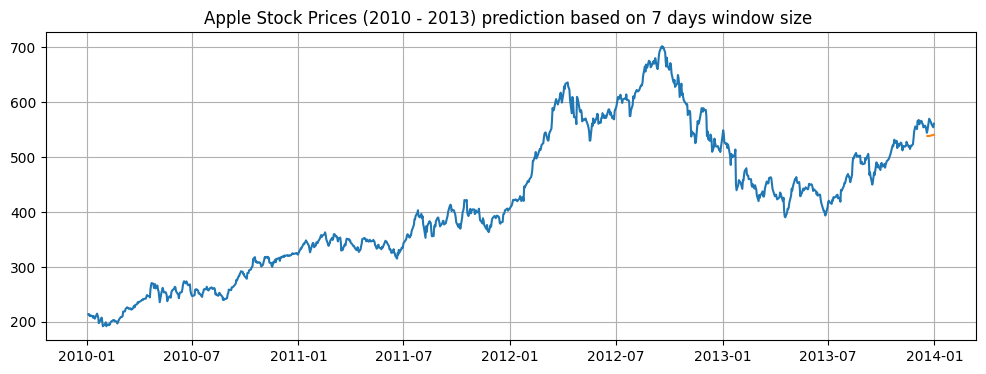

In [201]:
model7 = chaky_RNN()
predict_future(model7, train_set_norm, test_set, 7)

Reshaped shape: torch.Size([30, 1, 1])
Epoch:  0 Loss: 0.01917917
Epoch: 10 Loss: 0.00303953
Epoch: 20 Loss: 0.00247438
Epoch: 30 Loss: 0.00001410
Epoch: 40 Loss: 0.00255866
Epoch: 50 Loss: 0.00061682
Epoch: 60 Loss: 0.00060597
Epoch: 70 Loss: 0.00011369
Epoch: 80 Loss: 0.00331969
Epoch: 90 Loss: 0.00282013


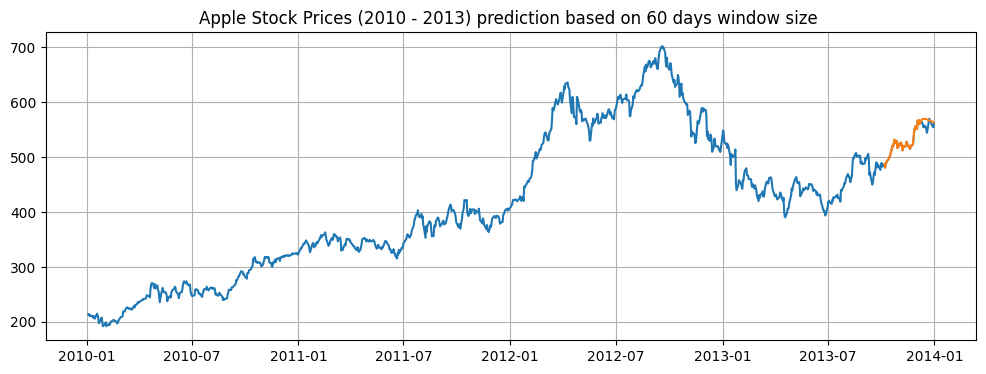

In [202]:
model60 = chaky_RNN()
predict_future(model60, train_set_norm, test_set, 60)



### **Impact of Window Size on LSTM Stock Price Prediction**

**Optimal Window Size: ws = 30**

The 30-day window produced the best predictions, providing sufficient historical context to capture medium-term trends whilst remaining responsive to recent changes. Predictions were smooth, stable, and closely followed actual prices without excessive lag.

**Small Window (ws = 7): Underfitting**

With only 7 days of history, the model exhibited underfitting. Predictions became noisy and unstable, as the network lacked sufficient context to identify trends, volatility, and momentum. The model reacted too strongly to short-term fluctuations, treating noise as signal.

**Large Window (ws = 60): Over-smoothing**

The 60-day window resulted in overfitting and slow reactions. Whilst predictions appeared smooth, they lagged behind actual data. The model struggled with long input sequences, giving equal weight to old and recent data, causing temporal inertia and delayed trend detection.

**Conclusion**

Window size selection requires balancing historical context with responsiveness. Too small leads to underfitting and noise sensitivity; too large causes over-smoothing and lag; 30 days achieves the optimal trade-off for accurate stock price prediction.


### **Which window size works best? Why?**

The 30-day window gives the best results.

It provides enough historical context for the LSTM to learn medium-term trends, while remaining responsive to changes. The predictions are smooth, stable, and closely follow the true price curve without excessive lag.

---

### **What happens when the window size is too small (ws=7)?**

A very small window leads to **underfitting**:

- The model only sees 7 days of history
- It cannot detect medium-term patterns
- Predictions become noisy and unstable
- LSTM reacts too strongly to recent fluctuations (noise)

As seen in the plot, ws=7 gives rough and less accurate predictions.

---

### **What happens when the window size is too large (ws=60)?**

A very large window leads to **overfitting + slow reactions**:

- Model tries to learn from too much history
- Old, irrelevant data affects prediction
- Model becomes slow to adapt to new trends
- Predictions become overly smooth and lag behind real data

This explains why ws=60 predictions look delayed even though they appear smooth.

# Exercise 2: Data Leakage - The Wrong Way

1. Replace the normalization code with this WRONG version:
```python
   # WRONG - fits scaler on ALL data (including test)
   y_all = df['Close'].values.astype('float')
   scaler = MinMaxScaler(feature_range=(-1, 1))
   y_all_norm = scaler.fit_transform(y_all.reshape(-1, 1)) 
   train_set_norm = y_all_norm[:-15]
```


In [204]:
y_all = df['close'].values.astype('float')
scaler = MinMaxScaler(feature_range=(-1, 1))
y_all_norm = scaler.fit_transform(y_all.reshape(-1, 1)) 
train_set_norm = y_all_norm[:-15]

In [207]:
train_data_ws7 = create_data(train_set_norm, 7)

In [208]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(-1, 1))

y_all_norm = scaler.fit_transform(y_all.reshape(-1, 1))
train_set_norm = y_all_norm[:-15]



2. Train and plot predictions

3. Compare with the original (correct) approach

4. Does it perform better or worse?  (Hint:  You will get better I think...)

5. Why is this result misleading and dangerous in real life?

## Workshop

1. What is RNN and what is the essence of this model?
2. In RNN, how many weights are there?  Which one is shared?  For example, if my sequence length is 100, how many matrix of weights I will have?  How about bias?
3. What is the shape of $\mathbf{x}_t$, $\mathbf{h}_t$, $\mathbf{W}_h$, $\mathbf{W}_x$, $\mathbf{b}$?
4. Given $\mathbf{x}_1$ of [[4], [3], [2], [1], [1]] as 5 samples in a time series data, $\mathbf{h}_0$ as [1, 2, 3, 4, 5], $\mathbf{W}_x$ as [[4, 3, -1, 2, 0]], $\mathbf{W}_h$ as $$\begin{bmatrix}
-3 & 2 & -1 & 4 & 0 \\
-1 & 1 & 0 & 2 & 0 \\
3 & -2 & 1 & 1 & 5 \\
-4 & 1 & -2 & 6 & -1 \\
-2 & 1 & -1 & 1 & 1
\end{bmatrix}$$, and $\mathbf{b}$ as [1, 1, 2, 2, 1], calculate $\mathbf{h}_1$, $\mathbf{h}_2$, and so on.  For simplicity, ignore the activation function.

1. Btw, in above code, what is the hidden size? What is the sequence length?